# Project 4: Phát hiện Tin giả sử dụng LSTM và DistilBERT trên Google Colab

Notebook này hướng dẫn chi tiết cách kết nối Google Drive, cấu hình môi trường, chạy các kịch bản huấn luyện tối ưu hóa siêu tham số (Grid Search), đánh giá kết quả và chạy demo phân loại tin tức (Real/Fake) sử dụng hai mô hình:
1. **LSTM Classifier** (Mạng nơ-ron hồi quy hai chiều + Max Pooling)
2. **DistilBERT** (Mô hình Transformer đã tinh chỉnh - Fine-tuning)

---

## Bước 1: Kết nối Google Drive để lưu kết quả huấn luyện vĩnh viễn

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Bước 2: Thiết lập thư mục làm việc và sao chép mã nguồn vào Google Drive
Chúng ta sẽ tạo thư mục dự án trên Drive để chứa mã nguồn, dữ liệu huấn luyện, và lưu lại các checkpoint mô hình cùng biểu đồ so sánh.

In [2]:
import os
import shutil

# Đường dẫn thư mục dự án trên Google Drive
DRIVE_PROJECT_PATH = "/content/drive/MyDrive/FakeNewsNet"
os.makedirs(DRIVE_PROJECT_PATH, exist_ok=True)

print(f"Thư mục dự án trên Google Drive: {DRIVE_PROJECT_PATH}")

Thư mục dự án trên Google Drive: /content/drive/MyDrive/FakeNewsNet


> **Lưu ý:** Bạn cần tải hoặc upload toàn bộ mã nguồn của dự án (bao gồm thư mục `fakenews_detection` và `dataset`) lên thư mục `FakeNewsNet` trên Google Drive của mình. Sau khi đã upload xong, hãy chuyển Colab đến thư mục này để thực thi mã nguồn.

In [11]:
%cd /content/drive/MyDrive/FakeNewsNet
!ls -la

/content/drive/MyDrive/FakeNewsNet
total 37
drwx------ 5 root root  4096 May 29 07:10 code
drwx------ 2 root root  4096 May 29 07:22 data_result
drwx------ 2 root root  4096 May 29 07:10 dataset
drwx------ 3 root root  4096 May 29 07:24 fakenews_detection
drwx------ 7 root root  4096 May 29 07:10 .git
-rw------- 1 root root 11940 May 29 06:33 README.md
-rw------- 1 root root   579 May 29 06:33 requirements.txt
drwx------ 5 root root  4096 May 29 10:40 result


## Bước 3: Cài đặt các thư viện cần thiết

In [4]:
!pip install -q transformers pandas scikit-learn matplotlib nltk

## Bước 4: Chạy Tiền xử lý dữ liệu (CHỈ CẦN CHẠY 1 LẦN DUY NHẤT)
Bước này gộp dữ liệu thô, làm sạch văn bản và phân tách thành `train.csv`, `val.csv`, và `test.csv` trong thư mục **`data_result`** trên Drive.

In [7]:
!python fakenews_detection/preprocessing.py --output_dir "/content/drive/MyDrive/FakeNewsNet/data_result"

Bắt đầu tiền xử lý dữ liệu từ: /content/drive/MyDrive/FakeNewsNet/dataset
Loading gossipcop_real.csv...
Loading gossipcop_fake.csv...
Loading politifact_real.csv...
Loading politifact_fake.csv...
Total combined dataset size: 23196
Class distribution:
label
0    17441
1     5755
Name: count, dtype: int64
Kích thước các tập sau phân chia (và cân bằng tập Train nếu có):
  - Train: 16237 mẫu (Real=12209, Fake=4028)
  - Val:   3479 mẫu (Real=2616, Fake=863)
  - Test:  3480 mẫu (Real=2616, Fake=864)
Đã lưu các tập dữ liệu:
  - Train: /content/drive/MyDrive/FakeNewsNet/data_result/train.csv
  - Val:   /content/drive/MyDrive/FakeNewsNet/data_result/val.csv
  - Test:  /content/drive/MyDrive/FakeNewsNet/data_result/test.csv
Trọng số lớp (Class weights - balanced) trên tập Train: [0.66496028 2.01551639]
Tiền xử lý hoàn tất thành công!


## Bước 5: Thực hiện Huấn luyện và Tối ưu hóa siêu tham số (Grid Search)

Chúng ta huấn luyện nhiều cấu hình. Các mô hình và checkpoint được lưu riêng biệt vào thư mục **`result/lstm`** và **`result/distilbert`**. Bảng so sánh tổng hợp được ghi vào `result/all_runs_results.csv`.

> **Mẹo tối ưu:** Do chạy toàn bộ Grid Search cho DistilBERT tốn rất nhiều thời gian trên Colab GPU, bạn có thể rút gọn mảng tham số bên dưới để chạy nhanh hơn.

In [3]:
# ==================== 1. HUẤN LUYỆN GRID SEARCH CHO LSTM ====================

lrs_lstm = [0.001, 0.0001]
dropouts = [0.1, 0.3, 0.5]
batch_sizes = [8, 16, 32]

print("Bắt đầu huấn luyện Grid Search cho LSTM...")
for lr in lrs_lstm:
    for drop in dropouts:
        for bs in batch_sizes:
            print(f"\n>>> RUNNING LSTM: lr={lr}, dropout={drop}, batch_size={bs}")
            !python /content/drive/MyDrive/FakeNewsNet/fakenews_detection/train.py \
                --model lstm \
                --data_dir "/content/drive/MyDrive/FakeNewsNet/data_result" \
                --lr {lr} \
                --dropout {drop} \
                --batch_size {bs} \
                --epochs 8 \
                --patience 3 \
                --output_dir "/content/drive/MyDrive/FakeNewsNet/result"

Bắt đầu huấn luyện Grid Search cho LSTM...

>>> RUNNING LSTM: lr=0.001, dropout=0.1, batch_size=8
Running on device: cuda
Đang tải dữ liệu tiền xử lý từ /content/drive/MyDrive/FakeNewsNet/data_result...
Loaded 16237 train, 3479 val, 3480 test samples.
Computed class weights: [0.66496028 2.01551639]
Built vocabulary with 10000 unique tokens.
Saved vocabulary to /content/drive/MyDrive/FakeNewsNet/result/lstm/vocab_lstm_lr0.001_drop0.1_bs8.pkl

--- Starting Training for LSTM ---
Epoch 1/8
  [Train] Loss: 0.5458 | Acc: 0.7585 | F1 (Macro): 0.6961
  [Val]   Loss: 0.5013 | Acc: 0.8129 | F1 (Macro): 0.7457
  --> Checkpoint saved to /content/drive/MyDrive/FakeNewsNet/result/lstm/checkpoint_lstm_lr0.001_drop0.1_bs8.pt (Best Val F1: 0.7457)
Epoch 2/8
  [Train] Loss: 0.4423 | Acc: 0.8157 | F1 (Macro): 0.7690
  [Val]   Loss: 0.4710 | Acc: 0.7902 | F1 (Macro): 0.7433
  --> No improvement. Early stopping counter: 1/3
Epoch 3/8
  [Train] Loss: 0.3878 | Acc: 0.8434 | F1 (Macro): 0.8040
  [Val]   Loss:

In [5]:
# ==================== 2. HUẤN LUYỆN GRID SEARCH CHO DISTILBERT ====================

lrs_bert = [2e-5, 5e-5]
dropouts = [0.1, 0.3, 0.5]
batch_sizes = [8, 16, 32]

print("Bắt đầu huấn luyện Grid Search cho DistilBERT...")
for lr in lrs_bert:
    for drop in dropouts:
        for bs in batch_sizes:
            print(f"\n>>> RUNNING DISTILBERT: lr={lr}, dropout={drop}, batch_size={bs}")
            !python fakenews_detection/train.py \
                --model distilbert \
                --data_dir "/content/drive/MyDrive/FakeNewsNet/data_result" \
                --lr {lr} \
                --dropout {drop} \
                --batch_size {bs} \
                --epochs 5 \
                --patience 2 \
                --output_dir "/content/drive/MyDrive/FakeNewsNet/result"

Bắt đầu huấn luyện Grid Search cho DistilBERT...

>>> RUNNING DISTILBERT: lr=2e-05, dropout=0.1, batch_size=8
Running on device: cuda
Đang tải dữ liệu tiền xử lý từ /content/drive/MyDrive/FakeNewsNet/data_result...
Loaded 16237 train, 3479 val, 3480 test samples.
Computed class weights: [0.66496028 2.01551639]
tokenizer_config.json: 100% 48.0/48.0 [00:00<00:00, 190kB/s]
vocab.txt: 100% 232k/232k [00:00<00:00, 5.04MB/s]
tokenizer.json: 100% 466k/466k [00:00<00:00, 5.72MB/s]
Loading distilbert-base-uncased with dropout=0.1...
config.json: 100% 483/483 [00:00<00:00, 2.40MB/s]
model.safetensors: 100% 268M/268M [00:01<00:00, 146MB/s]
Loading weights: 100% 100/100 [00:00<00:00, 985.33it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED

## Bước 6: Đánh giá và Vẽ các biểu đồ So sánh
Script `eval.py` sẽ nạp dữ liệu kiểm thử từ `data_result`, quét kết quả từ `result/all_runs_results.csv` để lấy mô hình tốt nhất của mỗi loại trong thư mục con, sau đó lưu các biểu đồ so sánh vào `result/charts/`.

In [7]:
!python fakenews_detection/eval.py \
    --data_dir "/content/drive/MyDrive/FakeNewsNet/data_result" \
    --output_dir "/content/drive/MyDrive/FakeNewsNet/result"

Running evaluation on device: cuda
Đang tải dữ liệu kiểm thử từ /content/drive/MyDrive/FakeNewsNet/data_result/test.csv...
Loaded 3480 test samples.

=================== Loading best LSTM model ===================
Best configuration found:
  Learning Rate: 0.001
  Dropout:       0.1
  Batch Size:    8
  Val F1-Score:  0.7615
  Test Accuracy: 0.8161

Classification Report for LSTM:
              precision    recall  f1-score   support

        Real       0.89      0.86      0.88      2616
        Fake       0.62      0.69      0.65       864

    accuracy                           0.82      3480
   macro avg       0.75      0.77      0.76      3480
weighted avg       0.82      0.82      0.82      3480

Confusion Matrix for LSTM:
[[2245  371]
 [ 269  595]]
Saved confusion matrix chart to /content/drive/MyDrive/FakeNewsNet/result/charts/confusion_matrix_lstm.png
Saved history curves to /content/drive/MyDrive/FakeNewsNet/result/charts

=================== Loading best DISTILBERT model ====

## Bước 7: Trực quan hóa Biểu đồ kết quả ngay trên Colab


Biểu đồ: confusion_matrix_distilbert.png


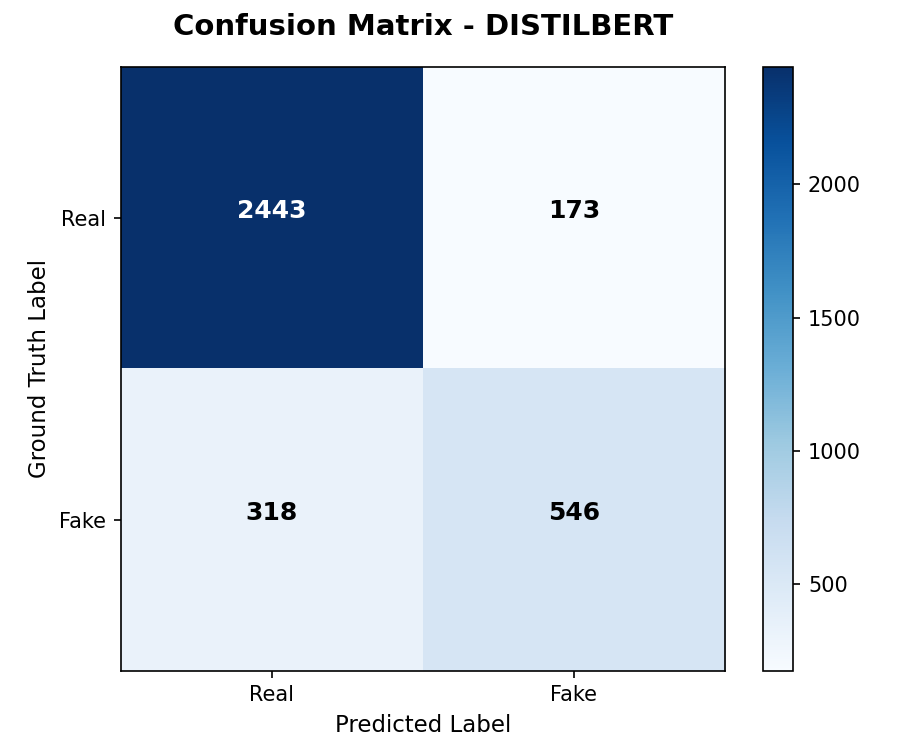


Biểu đồ: confusion_matrix_lstm.png


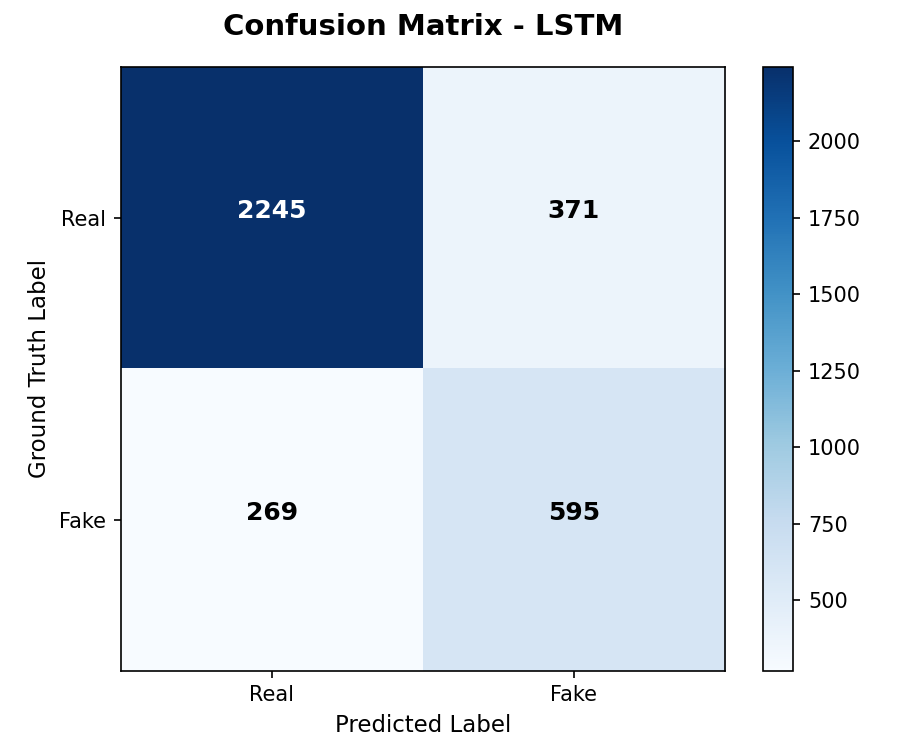


Biểu đồ: f1_curve_distilbert.png


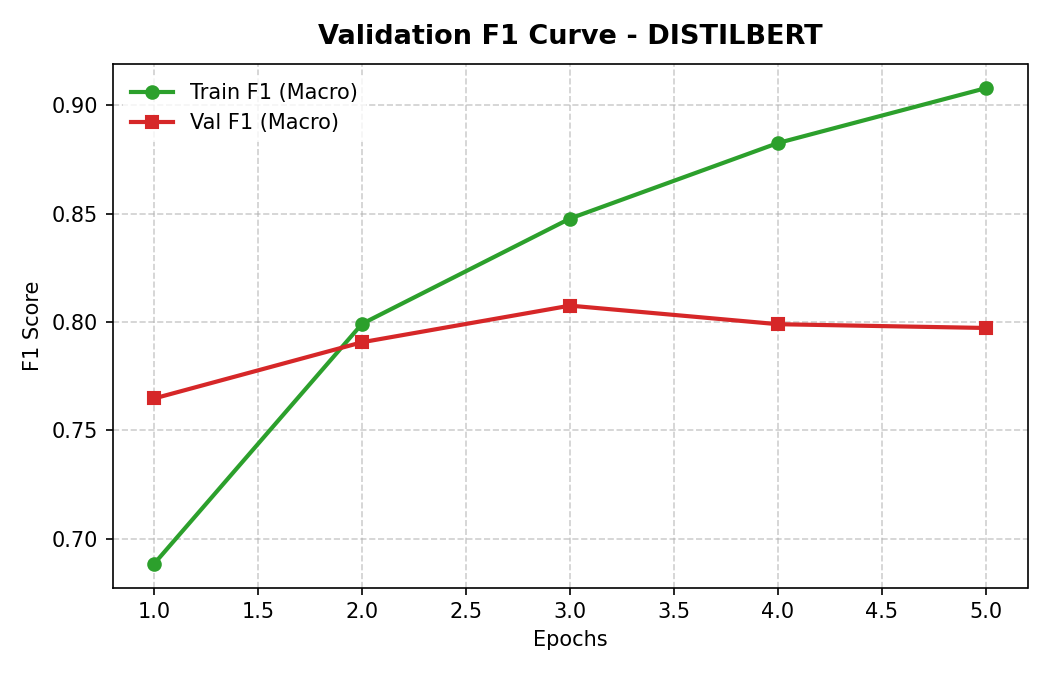


Biểu đồ: f1_curve_lstm.png


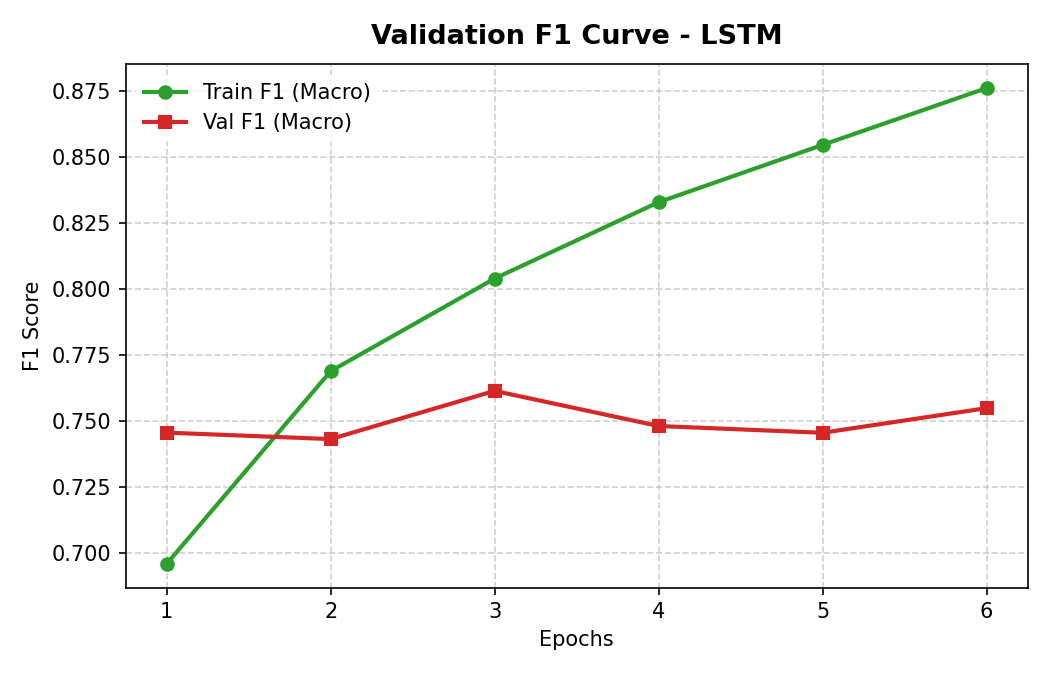


Biểu đồ: loss_curve_distilbert.png


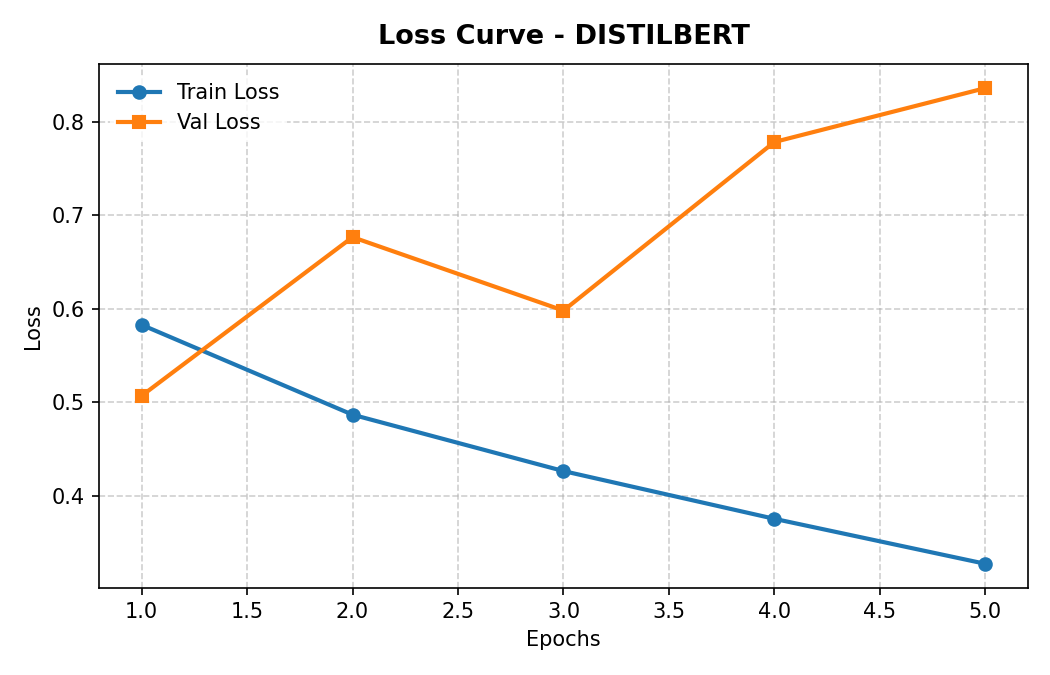


Biểu đồ: loss_curve_lstm.png


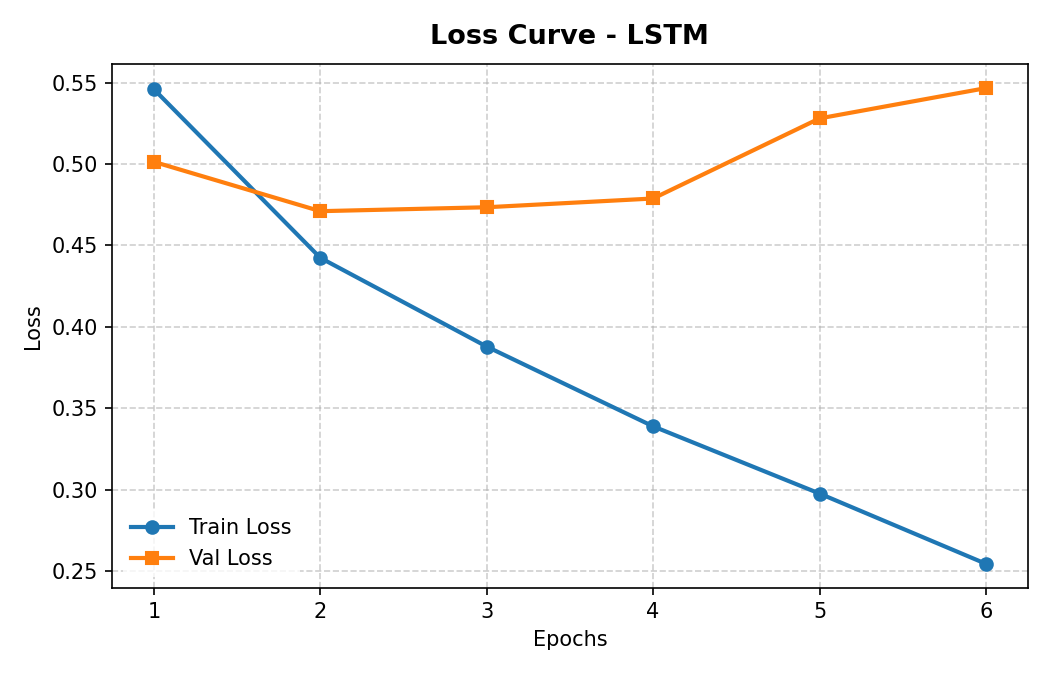


Biểu đồ: model_comparison_metrics.png


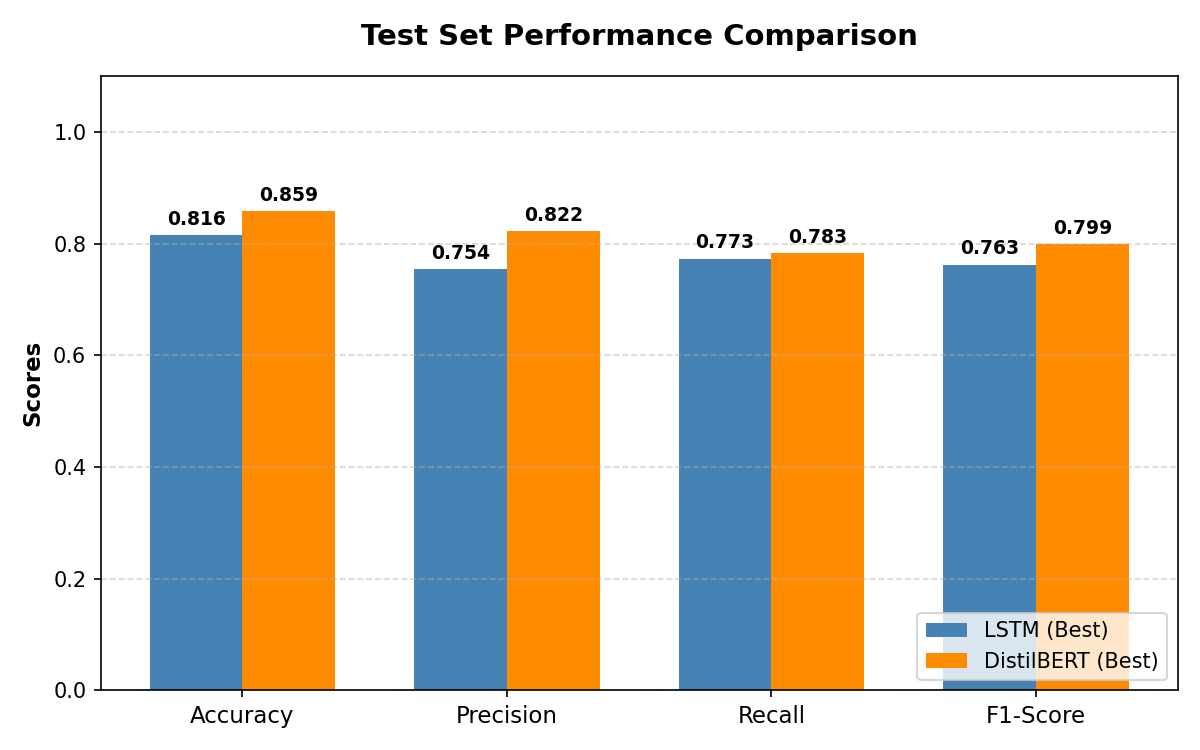

In [9]:
from IPython.display import Image, display
import glob
import os

charts = glob.glob("/content/drive/MyDrive/FakeNewsNet/result/charts/*.png")
for chart_path in sorted(charts):
    print(f"\nBiểu đồ: {os.path.basename(chart_path)}")
    display(Image(filename=chart_path))

## Bước 8: Trải nghiệm Demo Phân loại Tin tức (REAL/FAKE) Tương tác

In [10]:
# Chạy demo trực tiếp lấy từ thư mục lưu mô hình result/
!python fakenews_detection/demo.py \
    --output_dir "/content/drive/MyDrive/FakeNewsNet/result" \
    --text "Breaking: A new scientific breakthrough allows humans to live for 150 years."

Loading best models from '/content/drive/MyDrive/FakeNewsNet/result'...
Loading distilbert-base-uncased with dropout=0.3...
Loading weights: 100% 100/100 [00:00<00:00, 1811.82it/s, Materializing param=distilbert.transformer.layer.5.sa_layer_norm.weight]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on yo

In [16]:
from getpass import getpass

# 1. Điền thông tin tài khoản GitHub của bạn
GIT_USERNAME = "ThongThao"
GIT_EMAIL = "email_cua_ban@example.com"
REPO_NAME = "FakeNewsNet_Detection"

# Yêu cầu nhập Token bảo mật (đầu vào ẩn, không lưu vào file notebook)
GITHUB_TOKEN = getpass("Nhập GitHub Personal Access Token (PAT) của bạn: ")

# Cấu hình Git cục bộ
!git config --global user.name "{GIT_USERNAME}"
!git config --global user.email "{GIT_EMAIL}"
!git config --global http.postBuffer 524288000
!git config --global http.lowSpeedLimit 0
!git config --global http.lowSpeedTime 999999

# 2. Reset lại Git để xóa sạch commit cũ chứa Token lộ
!rm -rf .git
!git init
!git branch -M main
print("Đã làm sạch lịch sử Git lỗi.")

# 3. Tạo Remote URL bảo mật
REMOTE_URL = f"https://{GITHUB_TOKEN}@github.com/{GIT_USERNAME}/{REPO_NAME}.git"
!git remote add origin {REMOTE_URL}

# 4. Lưu lại các thay đổi mới và commit
!git add .
!git commit -m "Huấn luyện dự án Fake News Detection - Code bảo mật và biểu đồ kết quả"

# 5. Đẩy code lên GitHub
print("Đang đẩy code lên GitHub...")
!git push -u origin main --force
print("Hoàn tất! Dự án của bạn đã được cập nhật thành công lên GitHub.")

Nhập GitHub Personal Access Token (PAT) của bạn: ··········
hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/drive/MyDrive/FakeNewsNet/.git/
Đã làm sạch lịch sử Git lỗi.
[main (root-commit) 9929052] Huấn luyện dự án Fake News Detection - Code bảo mật và biểu đồ kết quả
 93 files changed, 51709 insertions(+)
 create mode 100644 .gitignore
 create mode 100644 README.md
 create mode 100644 code/config.json
 create mode 100644 code/main.py
 create mode 100644 code/news_content_collection.py
 create mode 100644 code/re

In [14]:
import os

gitignore_path = "/content/drive/MyDrive/FakeNewsNet/.gitignore"
if os.path.exists(gitignore_path):
    os.remove(gitignore_path)
    print("Đã xóa thành công tệp .gitignore trên Google Drive.")
else:
    print("Không tìm thấy tệp .gitignore tại đường dẫn chỉ định.")

Không tìm thấy tệp .gitignore tại đường dẫn chỉ định.
